# 02 · Pregame features
Checks on the team-game stats (`src/team_stats.py`) and the pregame feature table (`src/features.py`).

In [1]:
import sys; sys.path.append('..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.config import PROCESSED_DIR
from src.features import FEATURE_COLUMNS
from src.elo import elo_prob

tg = pd.read_parquet(PROCESSED_DIR / 'team_games.parquet')
games = pd.read_parquet(PROCESSED_DIR / 'games_features.parquet')
played = games[games.home_win.notna() & (games.season >= 2007)]  # 2006 is burn-in
print(tg.shape, games.shape, played.shape)

(10924, 44) (5703, 117) (5181, 117)


## In-game EPA margin vs. point differential
If EPA measures team quality, the per-game EPA margin should track the scoreboard closely.

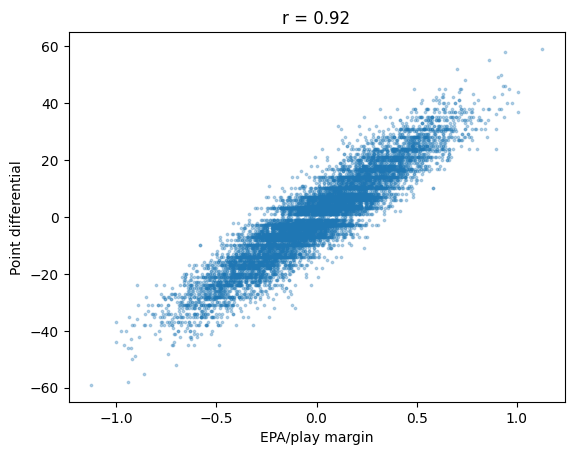

In [2]:
m = tg.off_epa_per_play - tg.def_epa_per_play
plt.scatter(m, tg.point_diff, s=3, alpha=0.3)
plt.xlabel('EPA/play margin'); plt.ylabel('Point differential')
plt.title(f'r = {m.corr(tg.point_diff):.2f}'); plt.show()

## How early-season features converge
Pregame offensive EPA for one team through a season: week 1 leans on last year, then shifts to this year.

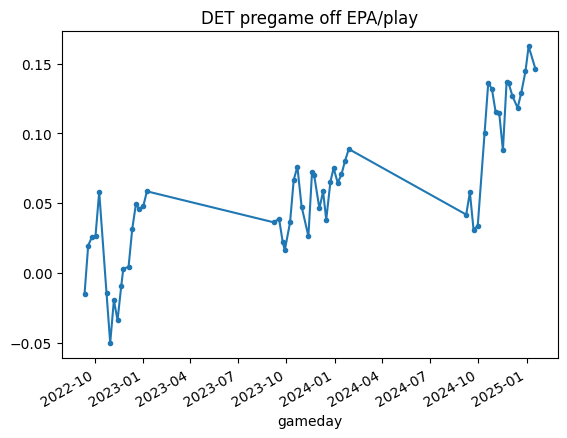

In [3]:
from src.features import build_team_features
team = build_team_features(tg)
ex = team[(team.team == 'DET') & team.season.between(2022, 2024)]
ex.plot(x='gameday', y='off_epa_per_play', marker='.', legend=False, title='DET pregame off EPA/play')
plt.show()

## Which pregame features line up with winning?
Correlation of each home-minus-away feature with `home_win`.

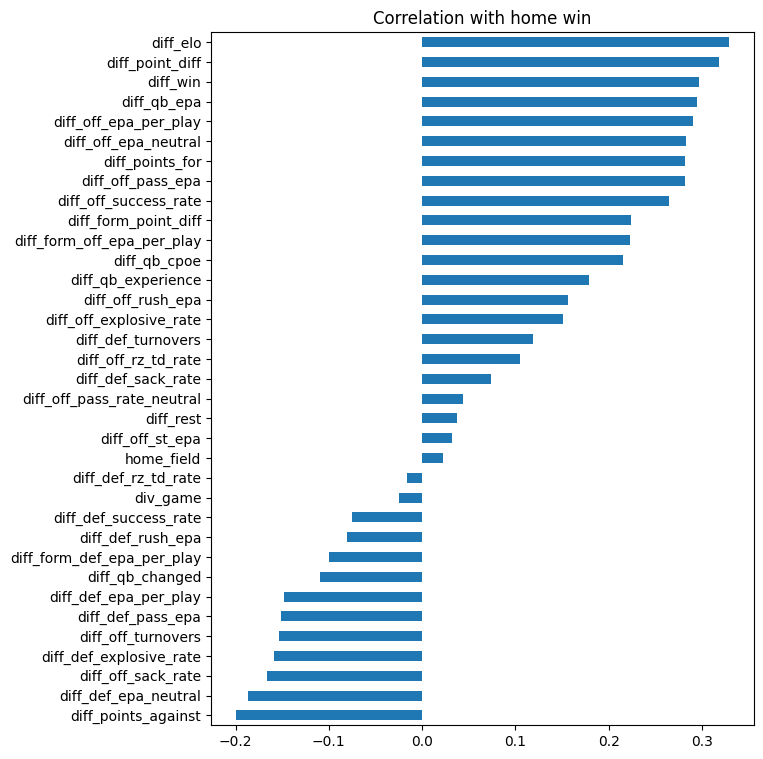

In [4]:
c = played[FEATURE_COLUMNS].corrwith(played.home_win).sort_values()
c.plot.barh(figsize=(7, 9), title='Correlation with home win'); plt.show()

## Baselines to beat
Always-home, Elo, and the Vegas moneyline (vig removed).

In [5]:
def ml_to_prob(ml):
    return np.where(ml < 0, -ml / (-ml + 100), 100 / (ml + 100))

v = played.dropna(subset=['home_moneyline', 'away_moneyline'])
ph, pa = ml_to_prob(v.home_moneyline), ml_to_prob(v.away_moneyline)
p_vegas = ph / (ph + pa)
p_elo = elo_prob(v.diff_elo + np.where(v.neutral, 0, 48))
y = v.home_win

def report(name, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    ll = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    print(f'{name:12s} acc={((p > 0.5) == (y == 1)).mean():.3f}  logloss={ll:.4f}  brier={np.mean((p - y)**2):.4f}')

report('Always home', np.full(len(v), y.mean()))
report('Elo', p_elo)
report('Vegas', p_vegas)

Always home  acc=0.558  logloss=0.6864  brier=0.2466
Elo          acc=0.647  logloss=0.6288  brier=0.2196
Vegas        acc=0.667  logloss=0.6071  brier=0.2100
